In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV

# Load the dataset
file_path = '../dataset_for_modeling/features_for_ranking.csv'
rank_teams = pd.read_csv(file_path)

feature_columns = [
    "player_awards", "net_rating", "off_eff", "def_eff", "home_win_pct",
    "away_win_pct", "reb_dif", "conf_win_pct", "ast_dif", "blk_dif",
    "pf_dif", "coach_awards", "efg_pct", "win_pct", "pts_per_poss",
    "ts_pct", "eff_x_pace", "net_four_factors", "pyth_wins"
]

# Add 'rank' and 'confID' for lagging and grouping
base_columns = feature_columns + ['rank', 'confID']

# Ensure data is sorted by team and year for correct lagging
rank_teams = rank_teams.sort_values(by=['tmID', 'year'])


In [13]:
# 1. Create Lag-1 Features (Last Year's Stats)
lag1_feature_names = [f"{col}_lag1" for col in base_columns]
rank_teams[lag1_feature_names] = rank_teams.groupby('tmID')[base_columns].shift(1)

# 2. Create 3-Year Rolling Avg Features
cols_to_weight = feature_columns + ['rank']
avg3yr_feature_names = [f"{col}_avg3yr_lag" for col in cols_to_weight]

# Define the weighted average function
def weighted_avg(series):
    weights = np.array([0.2, 0.3, 0.5])  # Weights for 3 years
    w = weights[-len(series):] # Adjust for windows smaller than 3
    return np.sum(series * w) / np.sum(w)

# Calculate rolling average on the lag-1 features
rolling_avg_features = rank_teams.groupby('tmID')[[f"{col}_lag1" for col in cols_to_weight]] \
                                 .rolling(window=3, min_periods=1) \
                                 .apply(weighted_avg, raw=True)

# Align the rolling average index
rank_teams[avg3yr_feature_names] = rolling_avg_features.reset_index(level=0, drop=True)

# 3. Clean Data
# Remove all rows with NaN values. This removes:
# a) The first year for every team (no lag-1 data)
# b) The first two years if using min_periods=3 for rolling avg
model_df = rank_teams.dropna(subset=lag1_feature_names + avg3yr_feature_names)

print(f"Original shape: {rank_teams.shape}, Model-ready shape: {model_df.shape}")


Original shape: (142, 65), Model-ready shape: (83, 65)


In [14]:
# The target is always the rank of the CURRENT year
target_col = 'rank'

# Experiment A: Use only last year's stats
features_lag1 = [f"{col}_lag1" for col in feature_columns] + ['rank_lag1']

# Experiment B: Use only the 3-year average stats
features_avg3yr = [f"{col}_avg3yr_lag" for col in feature_columns] + ['rank_avg3yr_lag']

# Experiment C: Use both sets
features_combined = features_lag1 + features_avg3yr

feature_sets = {
    "Lag 1 Only": features_lag1,
    "Avg 3-Year Only": features_avg3yr,
    "Combined": features_combined
}


In [15]:
TEST_YEAR = 10
VALIDATION_YEAR = 9

# Train: All years BEFORE the validation year
train_df = model_df[model_df['year'] < VALIDATION_YEAR] # Years 2-8
y_train = train_df[target_col]

# Validate: Only the validation year
val_df = model_df[model_df['year'] == VALIDATION_YEAR] # Year 9
y_val = val_df[target_col]

# Test: Only the test year
test_df = model_df[model_df['year'] == TEST_YEAR] # Year 10
y_test = test_df[target_col]

print(f"Training observations: {len(train_df)}")
print(f"Validation observations: {len(val_df)}")
print(f"Test observations: {len(test_df)}")


Training observations: 59
Validation observations: 12
Test observations: 12


In [16]:
# Get the baseline prediction (last year's rank)
y_pred_baseline = val_df['rank_lag1']

y_pred_baseline.head()

# Evaluate baseline on the Validation set
mae_baseline = mean_absolute_error(y_val, y_pred_baseline)
spearman_baseline, _ = spearmanr(y_val, y_pred_baseline)

print("--- Baseline Model (on Validation Set) ---")
print(f"  MAE: {mae_baseline:.4f}")
print(f"  Spearman Rank: {spearman_baseline:.4f}")


--- Baseline Model (on Validation Set) ---
  MAE: 1.5833
  Spearman Rank: 0.3826


In [17]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

results = []

for fs_name, fs_cols in feature_sets.items():
    print(f"\n--- Testing Feature Set: {fs_name} ---")
    
    # Define X data based on the current feature set
    X_train = train_df[fs_cols]
    X_val = val_df[fs_cols]

    # Scale data (important for Linear Regression)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    for name, model in models.items():
        # Fit model
        if name == 'Linear Regression':
            model.fit(X_train_scaled, y_train)
            y_pred_val = model.predict(X_val_scaled)
        else:
            model.fit(X_train, y_train) # Tree models don't require scaling
            y_pred_val = model.predict(X_val)
        
        # Evaluate model
        mae = mean_absolute_error(y_val, y_pred_val)
        spearman_corr, _ = spearmanr(y_val, y_pred_val)
        
        print(f"  Model: {name}")
        print(f"    MAE: {mae:.4f} (Baseline: {mae_baseline:.4f})")
        print(f"    Spearman: {spearman_corr:.4f} (Baseline: {spearman_baseline:.4f})")
        
        results.append((fs_name, name, mae, spearman_corr))

# Find the best model based on validation Spearman score
best_result = max(results, key=lambda item: item[3])
best_fs_name, best_model_name, best_mae, best_spearman = best_result

print(f"\n--- Best Model from Validation ---")
print(f"  Feature Set: {best_fs_name}")
print(f"  Model: {best_model_name}")
print(f"  Spearman: {best_spearman:.4f}")



--- Testing Feature Set: Lag 1 Only ---
  Model: Linear Regression
    MAE: 2.0904 (Baseline: 1.5833)
    Spearman: -0.0988 (Baseline: 0.3826)
  Model: Random Forest
    MAE: 1.8867 (Baseline: 1.5833)
    Spearman: -0.1587 (Baseline: 0.3826)
  Model: Gradient Boosting
    MAE: 1.9586 (Baseline: 1.5833)
    Spearman: -0.1129 (Baseline: 0.3826)

--- Testing Feature Set: Avg 3-Year Only ---
  Model: Linear Regression
    MAE: 2.1035 (Baseline: 1.5833)
    Spearman: -0.0705 (Baseline: 0.3826)
  Model: Random Forest
    MAE: 1.7042 (Baseline: 1.5833)
    Spearman: 0.2222 (Baseline: 0.3826)
  Model: Gradient Boosting
    MAE: 1.6219 (Baseline: 1.5833)
    Spearman: 0.1728 (Baseline: 0.3826)

--- Testing Feature Set: Combined ---
  Model: Linear Regression
    MAE: 2.1892 (Baseline: 1.5833)
    Spearman: 0.0952 (Baseline: 0.3826)
  Model: Random Forest
    MAE: 1.7642 (Baseline: 1.5833)
    Spearman: 0.0600 (Baseline: 0.3826)
  Model: Gradient Boosting
    MAE: 1.6740 (Baseline: 1.5833)
    

In [18]:
# Get the best features and prepare data
best_model = models[best_model_name]
best_features = feature_sets[best_fs_name]

# Combine Train + Validation data
X_train_full = pd.concat([train_df[best_features], val_df[best_features]])
y_train_full = pd.concat([y_train, y_val])

if best_model_name == 'Random Forest':
    print(f"--- Optimizing {best_model_name} with Grid Search ---")

    param_grid = {
        'n_estimators': [100, 200, 300],        # Number of trees
        'max_depth': [None, 5, 10, 20],         # Max depth of trees (controls overfitting)
        'min_samples_split': [2, 5, 10],        # Minimum samples required to split a node
        'min_samples_leaf': [1, 2, 4]           # Minimum samples required at a leaf node
    }

    # cv=3: Uses 3-fold cross-validation to be robust
    # n_jobs=-1: Uses all available CPU cores for speed
    grid_search = GridSearchCV(
        estimator=RandomForestRegressor(random_state=42),
        param_grid=param_grid,
        cv=3,
        scoring='neg_mean_absolute_error', # Optimize for MAE
        n_jobs=-1,
        verbose=1
    )

    # Fit the Grid Search to find the best parameters
    grid_search.fit(X_train_full, y_train_full)

    print(f"Best Hyperparameters: {grid_search.best_params_}")

    final_model = grid_search.best_estimator_

else:
    # Fallback for other models
    if best_model_name == 'Linear Regression':
        scaler = StandardScaler()
        X_train_full_scaled = scaler.fit_transform(X_train_full)
        final_model = best_model.fit(X_train_full_scaled, y_train_full)
    else:
        final_model = best_model.fit(X_train_full, y_train_full)

print(f"Final optimized model '{best_model_name}' trained on {len(X_train_full)} observations.")


--- Optimizing Random Forest with Grid Search ---
Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best Hyperparameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}
Final optimized model 'Random Forest' trained on 71 observations.



--- Baseline Model Evaluation (on Test Set: Year 10) ---
  MAE: 2.2500
  Spearman Rank: 0.0000


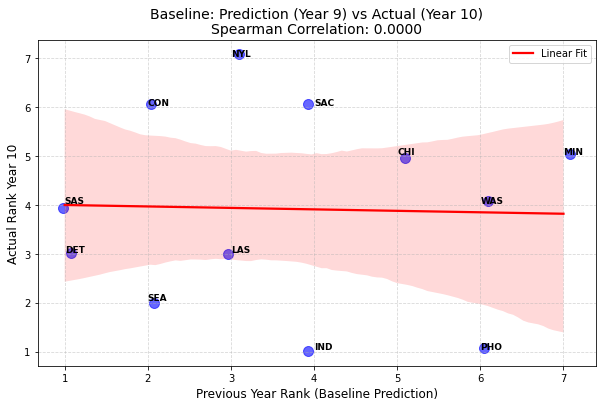

In [19]:
# --- Baseline for the final test set
y_pred_baseline_test = test_df['rank_lag1']
mae_baseline_test = mean_absolute_error(y_test, y_pred_baseline_test)
spearman_baseline_test, _ = spearmanr(y_test, y_pred_baseline_test)

print("\n--- Baseline Model Evaluation (on Test Set: Year 10) ---")
print(f"  MAE: {mae_baseline_test:.4f}")
print(f"  Spearman Rank: {spearman_baseline_test:.4f}")

plt.figure(figsize=(10, 6))

# Create Plot (Scatter + Regression Line)
# x_jitter helps to see overlapping points (e.g., two teams that were rank 1)
sns.regplot(x='rank_lag1', y='rank', data=test_df, 
            x_jitter=0.1, y_jitter=0.1, 
            scatter_kws={'s': 100, 'alpha': 0.6, 'color': 'blue'},
            line_kws={'color': 'red', 'label': 'Linear Fit'})

# Add Labels (Team Name) to each point
for i, row in test_df.iterrows():
    plt.text(row['rank_lag1'], row['rank'], row['tmID'], 
             fontsize=9, ha='left', va='bottom', fontweight='bold')

plt.title(f"Baseline: Prediction (Year 9) vs Actual (Year 10)\nSpearman Correlation: {spearman_baseline_test:.4f}", fontsize=14)
plt.xlabel("Previous Year Rank (Baseline Prediction)", fontsize=12)
plt.ylabel("Actual Rank Year 10", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()



In [20]:
# Prepare the Test set data
X_test = test_df[best_features]
y_test_final = test_df[target_col]

# Scale test data (if needed)
if best_model_name == 'Linear Regression':
    X_test_scaled = scaler.transform(X_test)
    y_pred_final = final_model.predict(X_test_scaled)
else:
    y_pred_final = final_model.predict(X_test)

# Evaluate
mae_final = mean_absolute_error(y_test_final, y_pred_final)
rmse_final = np.sqrt(mean_squared_error(y_test_final, y_pred_final))
spearman_final, _ = spearmanr(y_test_final, y_pred_final)

print("\n--- Final Model Evaluation (on Test Set: Year 10) ---")
print(f"  MAE: {mae_final:.4f}")
print(f"  RMSE: {rmse_final:.4f}")
print(f"  Spearman Rank: {spearman_final:.4f}")



--- Final Model Evaluation (on Test Set: Year 10) ---
  MAE: 1.4241
  RMSE: 1.8176
  Spearman Rank: 0.4233


In [21]:
# Create the final results DataFrame
final_results_df = test_df[['tmID', 'confID', 'year', 'rank', 'rank_lag1']].copy()
final_results_df.rename(columns={'rank': 'actual_rank', 'rank_lag1': 'baseline_rank'}, inplace=True)
final_results_df['predicted_rank_raw'] = y_pred_final

# Rank the model's raw predictions to get a 1-N ranking
final_results_df['predicted_rank_model'] = final_results_df.groupby('confID')['predicted_rank_raw'] \
                                                          .rank(method='first', ascending=True) \
                                                          .astype(int)

# Sort for easy viewing
final_results_df = final_results_df.sort_values(by=['confID', 'actual_rank'])

print("\n--- Final Predicted vs. Actual Rankings (Year 10) ---")
print(final_results_df[['confID', 'tmID', 'actual_rank', 'baseline_rank', 'predicted_rank_model']].to_string(index=False))

improvement_pct = ((mae_baseline_test - mae_final) / mae_baseline_test) * 100

print(f"\n--- Performance Comparison ---")
print(f"Baseline Error (Previous Year Rank): {mae_baseline_test:.4f}")
print(f"Model Error (With Custom Features): {mae_final:.4f}")
print(f"--------------------------------------------------")
print(f"TOTAL IMPROVEMENT: {improvement_pct:.2f}%")



--- Final Predicted vs. Actual Rankings (Year 10) ---
confID tmID  actual_rank  baseline_rank  predicted_rank_model
    EA  IND            1            4.0                     2
    EA  DET            3            1.0                     3
    EA  WAS            4            6.0                     6
    EA  CHI            5            5.0                     4
    EA  CON            6            2.0                     1
    EA  NYL            7            3.0                     5
    WE  PHO            1            6.0                     3
    WE  SEA            2            2.0                     2
    WE  LAS            3            3.0                     1
    WE  SAS            4            1.0                     4
    WE  MIN            5            7.0                     6
    WE  SAC            6            4.0                     5

--- Performance Comparison ---
Baseline Error (Previous Year Rank): 2.2500
Model Error (With Custom Features): 1.4241
--------------------

In [22]:
# Ver site do professor
# Ver equipas que n aparecem (por so ter ano 9 e 10)
